In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
file_path = "COM7_2026_03_16.21.40.01.788.txt"

df = pd.read_csv(file_path, header=None, names=["time_ms", "red", "ir"])
df.head()

,time_ms,red,ir
0,974748,121832,151226
1,974788,121783,151158
2,974828,121776,151227
3,974868,121814,151357
4,974908,121863,151487


In [16]:
print(df.shape)
print(df.head())
print(df.tail())
print(df.describe())

(1387, 3)
   time_ms     red      ir
0   974748  121832  151226
1   974788  121783  151158
2   974828  121776  151227
3   974868  121814  151357
4   974908  121863  151487
      time_ms     red      ir
1382  1030043  119321  149000
1383  1030083  119401  149271
1384  1030123  119473  149471
1385  1030163  119478  149517
1386  1030203  119456  149478
            time_ms            red             ir
count  1.387000e+03    1387.000000    1387.000000
mean   1.002475e+06  119940.239366  148951.242970
std    1.602579e+04     718.756011    1157.458367
min    9.747480e+05  118823.000000  146389.000000
25%    9.886110e+05  119390.000000  148115.000000
50%    1.002474e+06  119745.000000  148966.000000
75%    1.016338e+06  120413.000000  149711.000000
max    1.030203e+06  122083.000000  152411.000000


In [17]:
df["time_s"] = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000.0
df.head()

,time_ms,red,ir,time_s
0,974748,121832,151226,0.00
1,974788,121783,151158,0.04
2,974828,121776,151227,0.08
3,974868,121814,151357,0.12
4,974908,121863,151487,0.16


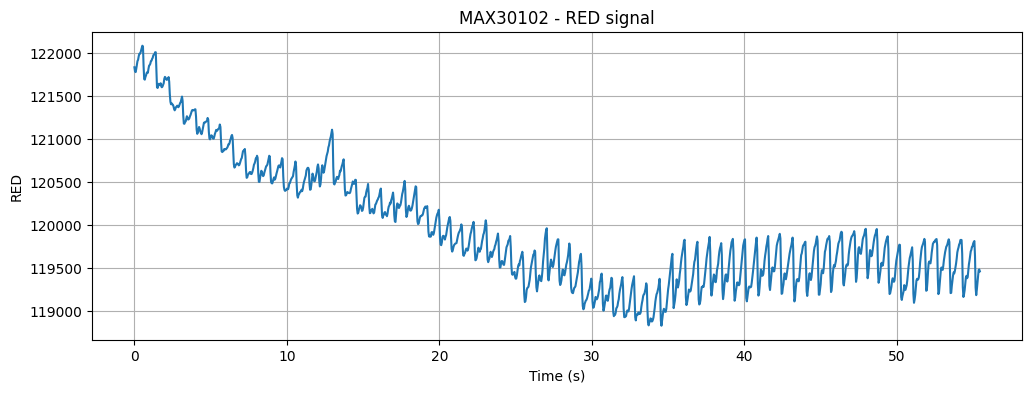

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(df["time_s"], df["red"])
plt.xlabel("Time (s)")
plt.ylabel("RED")
plt.title("MAX30102 - RED signal")
plt.grid(True)
plt.show()

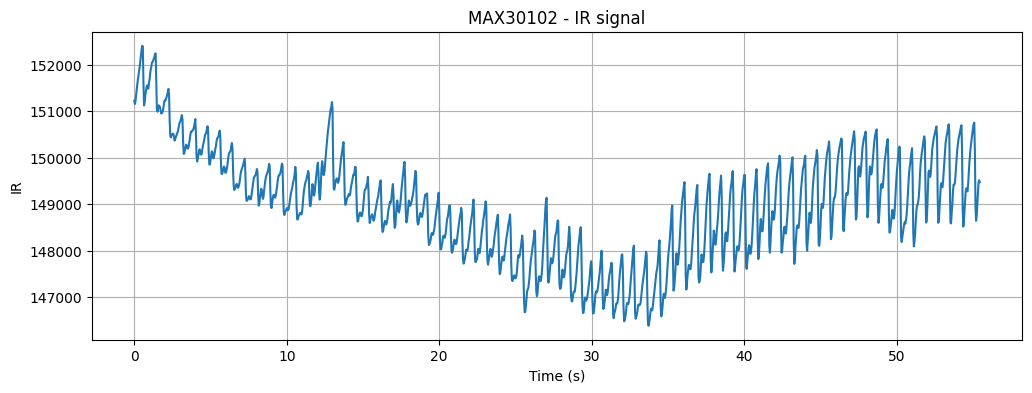

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(df["time_s"], df["ir"])
plt.xlabel("Time (s)")
plt.ylabel("IR")
plt.title("MAX30102 - IR signal")
plt.grid(True)
plt.show()

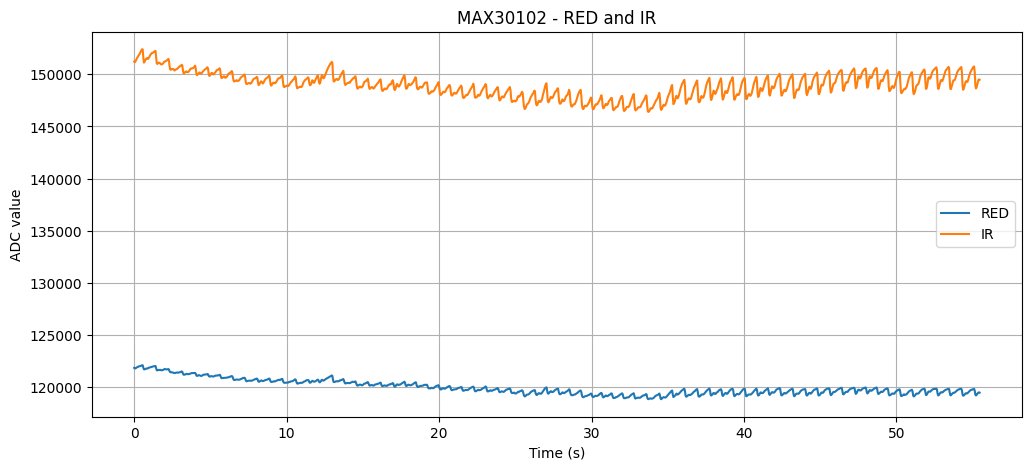

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["red"], label="RED")
plt.plot(df["time_s"], df["ir"], label="IR")
plt.xlabel("Time (s)")
plt.ylabel("ADC value")
plt.title("MAX30102 - RED and IR")
plt.legend()
plt.grid(True)
plt.show()

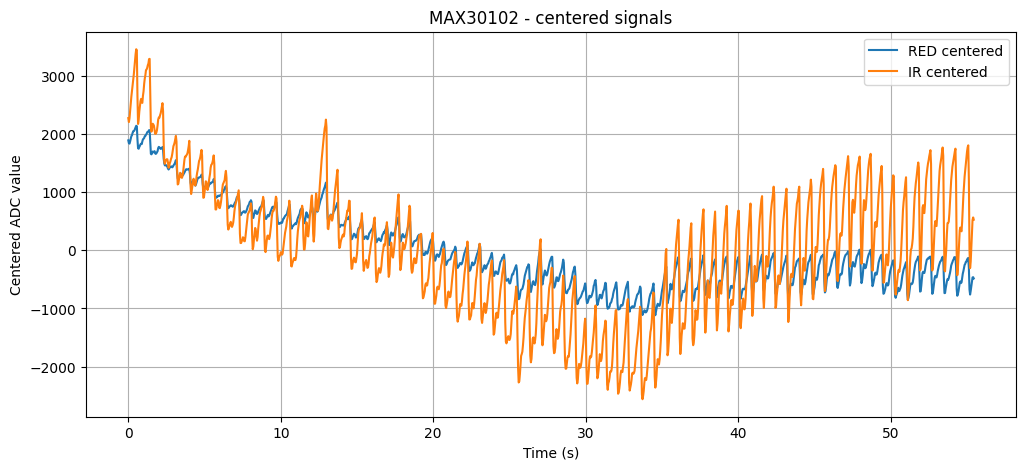

In [21]:
df["red_centered"] = df["red"] - df["red"].mean()
df["ir_centered"] = df["ir"] - df["ir"].mean()

plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["red_centered"], label="RED centered")
plt.plot(df["time_s"], df["ir_centered"], label="IR centered")
plt.xlabel("Time (s)")
plt.ylabel("Centered ADC value")
plt.title("MAX30102 - centered signals")
plt.legend()
plt.grid(True)
plt.show()

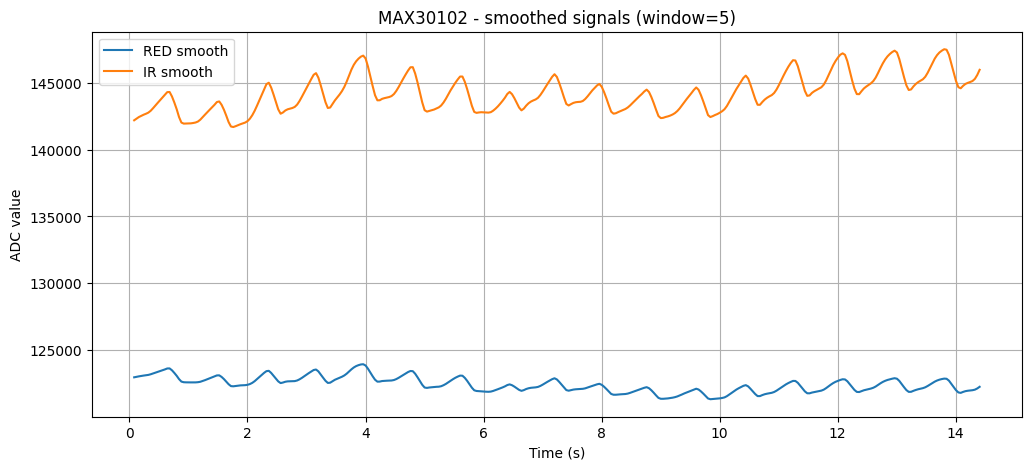

In [14]:
window = 5
df["red_smooth"] = df["red"].rolling(window=window, center=True).mean()
df["ir_smooth"] = df["ir"].rolling(window=window, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["red_smooth"], label="RED smooth")
plt.plot(df["time_s"], df["ir_smooth"], label="IR smooth")
plt.xlabel("Time (s)")
plt.ylabel("ADC value")
plt.title(f"MAX30102 - smoothed signals (window={window})")
plt.legend()
plt.grid(True)
plt.show()